# Squat Form Detection — Real Data Pipeline
**Files:** `Good1_data.csv` (motion capture kinematics) + `stream_Apple_Watch_*.csv` (Watch IMU)

---
### What you have right now
| File | Source | Content | Rate | Duration |
|------|--------|---------|------|----------|
| `Good1_data.csv` | Vicon C3D export | L/R Knee + Hip Angles & Accels (X,Y,Z) | ~100 Hz | ~25 sec |
| `stream_Apple_Watch_*.csv` | SensorLog | Full IMU + attitude | ~29 Hz | ~50 sec |

### What this notebook does
- **Cell 1–4:** Load, clean, and visualize both files independently
- **Cell 5:** Resample both to a common rate + align by relative time
- **Cell 6:** Sliding window → feature matrix
- **Cell 7:** Autoencoder (trains now — good squat only, flags anomalies)
- **Cell 8–10:** SVM, 1D-CNN, TCN stubs — ready to run once you add more trials
- **Cell 11:** Comparison plot

## Cell 0 — Install

In [7]:
!pip install numpy pandas scikit-learn matplotlib seaborn torch joblib scipy
!pip install coremltools

## Cell 1 — Imports & Config

In [9]:
# Watch placement: RIGHT leg, ABOVE knee (distal thigh)
# Primary cave signal: gx (frontal plane rotation)
# Primary squat depth: az + pitch
# Secondary: roll (tracks valgus lean)

import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from scipy.signal import resample_poly
from math import gcd
warnings.filterwarnings('ignore')

# ── File paths ─────────────────────────────────────────────
# Put both files in the same folder as this notebook, or adjust paths
KINE_FILE = r'C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\Good1_data.csv'          # ← adjust path
IMU_FILE  = r'C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\stream Apple Watch 260330 14_38_29.csv'

# ── Rates (confirmed from file inspection) ────────────────
KINE_HZ   = 100       # motion capture rate — adjust if your C3D was at different rate
IMU_HZ    = 29        # Apple Watch SensorLog rate
TARGET_HZ = 29        # resample everything to this (Watch rate — no upsampling needed)

# ── Window config ─────────────────────────────────────────
WIN_SEC  = 1.5
OVERLAP  = 0.5
WIN_LEN  = int(WIN_SEC * TARGET_HZ)           # ~43 frames at 29Hz
STEP     = int(WIN_LEN * (1 - OVERLAP))       # ~21 frames

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Window: {WIN_LEN} frames ({WIN_SEC}s @ {TARGET_HZ}Hz)')
print(f'Device: {DEVICE}')

KINE_COLS = [
    'L_Knee_Angle_X', 'L_Knee_Angle_Y', 'L_Knee_Angle_Z',
    'R_Knee_Angle_X', 'R_Knee_Angle_Y', 'R_Knee_Angle_Z',
    'L_Hip_Angle_X',  'L_Hip_Angle_Y',  'L_Hip_Angle_Z',
    'R_Hip_Angle_X',  'R_Hip_Angle_Y',  'R_Hip_Angle_Z',
]

imu_cols = ['ax','ay','az','gx','gy','gz','pitch','roll','yaw']

ALL_FEATURES = KINE_COLS + imu_cols  # 21 channels total

Window: 43 frames (1.5s @ 29Hz)
Device: cpu


## Cell 2 — Load Kinematics (Good1_data.csv)
C3D export with 5-row header. Tab-separated. Frame index 1→N.

In [11]:
def load_kinematics(fpath):
    with open(fpath, 'r') as f:
        lines = f.readlines()

    # Auto-detect separator (Good1=tab, Good2/3=comma)
    sep = '\t' if '\t' in lines[4] else ','

    signal_row = lines[1].strip().split(sep)
    axis_row   = lines[4].strip().split(sep)
    cols = ['frame' if i==0 else f'{signal_row[i]}_{axis_row[i]}'
            for i in range(len(axis_row))]

    df = pd.read_csv(fpath, sep=sep, skiprows=5, header=None, names=cols)
    df['frame'] = pd.to_numeric(df['frame'], errors='coerce')
    for c in cols[1:]:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df = df.dropna(subset=['frame']).reset_index(drop=True)
    df['frame'] = df['frame'].astype(int)
    df = df.sort_values('frame').reset_index(drop=True)

    # Drop NaN kinematic rows (C3D padding at start/end)
    df = df.dropna(subset=KINE_COLS).reset_index(drop=True)

    # Reindex so time_s always starts at 0.0
    df['frame']  = np.arange(len(df))
    df['time_s'] = df['frame'] / KINE_HZ
    return df

kine = load_kinematics(KINE_FILE)
print(f'Kinematics: {kine.shape[0]} frames  |  {kine["time_s"].max():.2f} sec  |  {KINE_HZ} Hz')
print('Columns:', kine.columns.tolist())
print()

# Columns we care about
KINE_COLS = [
    'L_Knee_Angle_X', 'L_Knee_Angle_Y', 'L_Knee_Angle_Z',
    'R_Knee_Angle_X', 'R_Knee_Angle_Y', 'R_Knee_Angle_Z',
    'L_Hip_Angle_X',  'L_Hip_Angle_Y',  'L_Hip_Angle_Z',
    'R_Hip_Angle_X',  'R_Hip_Angle_Y',  'R_Hip_Angle_Z',
]
print('Key kinematics signal ranges (degrees):')
print(kine[KINE_COLS].describe().round(2).T[['mean','min','max','std']])

Kinematics: 2267 frames  |  22.66 sec  |  100 Hz
Columns: ['frame', 'L_Hip_Accel_X', 'L_Hip_Accel_Y', 'L_Hip_Accel_Z', 'L_Hip_Angle_X', 'L_Hip_Angle_Y', 'L_Hip_Angle_Z', 'L_Knee_Accel_X', 'L_Knee_Accel_Y', 'L_Knee_Accel_Z', 'L_Knee_Angle_X', 'L_Knee_Angle_Y', 'L_Knee_Angle_Z', 'R_Hip_Accel_X', 'R_Hip_Accel_Y', 'R_Hip_Accel_Z', 'R_Hip_Angle_X', 'R_Hip_Angle_Y', 'R_Hip_Angle_Z', 'R_Knee_Accel_X', 'R_Knee_Accel_Y', 'R_Knee_Accel_Z', 'R_Knee_Angle_X', 'R_Knee_Angle_Y', 'R_Knee_Angle_Z', 'time_s']

Key kinematics signal ranges (degrees):
                 mean     min     max    std
L_Knee_Angle_X -43.38 -124.55    3.40  35.76
L_Knee_Angle_Y  -3.23  -22.60    5.32   3.61
L_Knee_Angle_Z  -0.00   -0.09    0.05   0.01
R_Knee_Angle_X -42.86 -122.20   -1.46  35.77
R_Knee_Angle_Y   5.70   -5.30   22.58   3.20
R_Knee_Angle_Z   0.00   -0.06    0.06   0.01
L_Hip_Angle_X   45.05  -11.60  102.32  28.90
L_Hip_Angle_Y   12.33   -9.47   23.85   5.35
L_Hip_Angle_Z    2.31  -24.98   20.02   6.43
R_Hip_Angle

## Cell 3 — Load Apple Watch IMU

In [13]:
def load_watch_imu(fpath):
    df = pd.read_csv(fpath)

    # Rename to short names
    rename = {
        'loggingTime(txt)'               : 'timestamp',
        'motionUserAccelerationX(G)'      : 'ax',
        'motionUserAccelerationY(G)'      : 'ay',
        'motionUserAccelerationZ(G)'      : 'az',
        'motionRotationRateX(rad/s)'      : 'gx',
        'motionRotationRateY(rad/s)'      : 'gy',
        'motionRotationRateZ(rad/s)'      : 'gz',
        'motionPitch(rad)'                : 'pitch',
        'motionRoll(rad)'                 : 'roll',
        'motionYaw(rad)'                  : 'yaw',
        'accelerometerTimestamp_sinceReboot(s)': 'ts_raw',
    }
    df = df.rename(columns=rename)

    # Parse timestamp → seconds since start
    df['t'] = pd.to_datetime(df['timestamp'], utc=False)
    df['time_s'] = (df['t'] - df['t'].iloc[0]).dt.total_seconds()

    imu_cols = ['ax','ay','az','gx','gy','gz','pitch','roll','yaw']
    df = df[['time_s'] + imu_cols].dropna().reset_index(drop=True)
    return df

imu = load_watch_imu(IMU_FILE)
print(f'Watch IMU: {len(imu)} rows  |  {imu["time_s"].max():.2f} sec  |  ~{TARGET_HZ} Hz')
print('Columns:', imu.columns.tolist())
print()
print('IMU signal ranges:')
print(imu[['ax','ay','az','gx','gy','gz','pitch','roll']].describe().round(4).T[['mean','min','max','std']])

Watch IMU: 1485 rows  |  50.34 sec  |  ~29 Hz
Columns: ['time_s', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'pitch', 'roll', 'yaw']

IMU signal ranges:
         mean     min     max     std
ax    -0.0097 -0.7306  1.3616  0.1565
ay    -0.0027 -0.7608  1.4633  0.1467
az     0.0192 -2.3126  0.9408  0.2315
gx     0.1285 -2.9987  4.6052  0.6553
gy     0.0241 -6.1439  4.5687  1.0483
gz     0.0227 -1.6308  1.4519  0.2609
pitch -0.2399 -0.4001  0.0562  0.0803
roll   1.7305  0.9873  2.6015  0.3283


## Cell 4 — Visualize Both Signals
Quick sanity check before merging.

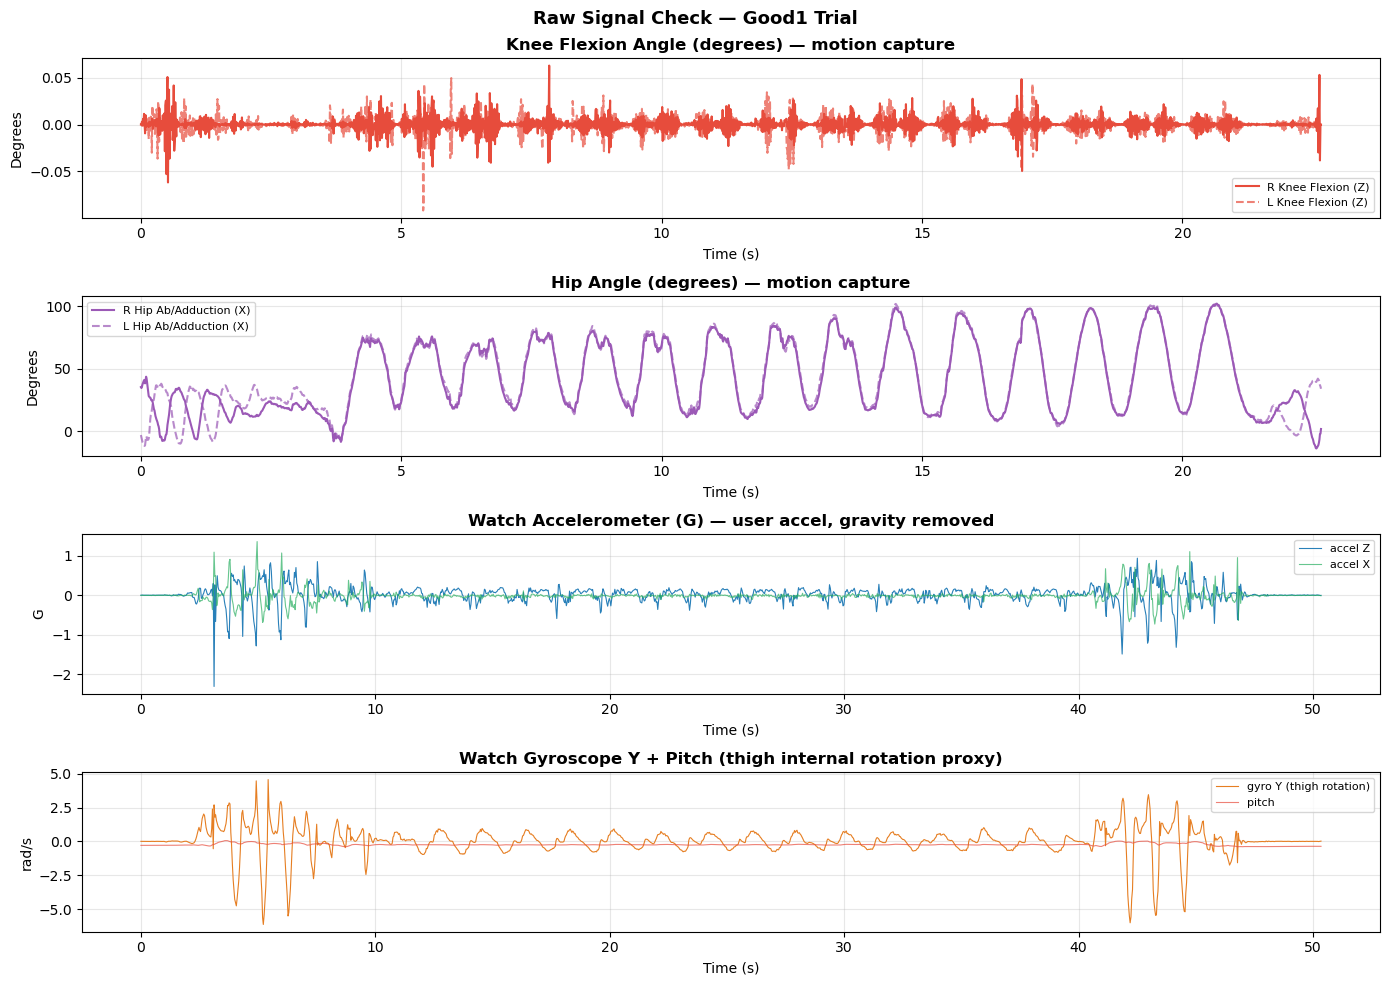

Saved → signal_check_real.png


In [15]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)

# Kinematics
axes[0].plot(kine['time_s'], kine['R_Knee_Angle_Z'], label='R Knee Flexion (Z)', color='#E74C3C')
axes[0].plot(kine['time_s'], kine['L_Knee_Angle_Z'], label='L Knee Flexion (Z)', color='#E74C3C', linestyle='--', alpha=0.7)
axes[0].set_title('Knee Flexion Angle (degrees) — motion capture', fontweight='bold')
axes[0].set_ylabel('Degrees'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(kine['time_s'], kine['R_Hip_Angle_X'], label='R Hip Ab/Adduction (X)', color='#9B59B6')
axes[1].plot(kine['time_s'], kine['L_Hip_Angle_X'], label='L Hip Ab/Adduction (X)', color='#9B59B6', linestyle='--', alpha=0.7)
axes[1].set_title('Hip Angle (degrees) — motion capture', fontweight='bold')
axes[1].set_ylabel('Degrees'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Watch IMU
axes[2].plot(imu['time_s'], imu['az'], label='accel Z', color='#2980B9', linewidth=0.8)
axes[2].plot(imu['time_s'], imu['ax'], label='accel X', color='#27AE60', linewidth=0.8, alpha=0.7)
axes[2].set_title('Watch Accelerometer (G) — user accel, gravity removed', fontweight='bold')
axes[2].set_ylabel('G'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

axes[3].plot(imu['time_s'], imu['gy'], label='gyro Y (thigh rotation)', color='#E67E22', linewidth=0.8)
axes[3].plot(imu['time_s'], imu['pitch'], label='pitch', color='#E74C3C', linewidth=0.8, alpha=0.7)
axes[3].set_title('Watch Gyroscope Y + Pitch (thigh internal rotation proxy)', fontweight='bold')
axes[3].set_ylabel('rad/s'); axes[3].legend(fontsize=8); axes[3].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel('Time (s)')

plt.suptitle('Raw Signal Check — Good1 Trial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('signal_check_real.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → signal_check_real.png')

## Cell 5 — Resample & Align

Both files are from the same recording session but may not start at exactly the same second.
Strategy: resample kinematics from 100Hz → 29Hz, then align by matching the **shorter** duration.

In [17]:
from scipy.interpolate import interp1d

def resample_to_hz(df, time_col, value_cols, target_hz):
    """
    Resample a DataFrame to target_hz using linear interpolation.
    Works for any input rate → any output rate.
    """
    t_orig = df[time_col].values
    t_new  = np.arange(t_orig[0], t_orig[-1], 1.0 / target_hz)

    out = {'time_s': t_new}
    for col in value_cols:
        f = interp1d(t_orig, df[col].values, kind='linear', fill_value='extrapolate')
        out[col] = f(t_new)
    return pd.DataFrame(out)

# Resample kinematics 100Hz → 29Hz
kine_rs = resample_to_hz(kine, 'time_s', KINE_COLS, TARGET_HZ)
print(f'Kinematics resampled: {len(kine_rs)} frames @ {TARGET_HZ}Hz ({kine_rs["time_s"].max():.2f}s)')

# IMU is already at ~29Hz — just confirm
imu_cols = ['ax','ay','az','gx','gy','gz','pitch','roll','yaw']
print(f'Watch IMU:            {len(imu)} frames @ {TARGET_HZ}Hz ({imu["time_s"].max():.2f}s)')

# ── Align by overlap ───────────────────────────────────────
# Both files start at t=0 (relative). Use shorter duration as the common window.
# NOTE: If the recordings didn't start at the same moment, you'll need to manually
# find a sync event (e.g., a jump visible in both signals) and set an offset below.

SYNC_OFFSET_SEC = 0.0  # ← adjust this if recordings started at different times

kine_rs['time_s'] = kine_rs['time_s'] + SYNC_OFFSET_SEC

# Find common time range
t_start = max(kine_rs['time_s'].min(), imu['time_s'].min())
t_end   = min(kine_rs['time_s'].max(), imu['time_s'].max())
print(f'\nCommon time window: {t_start:.2f}s → {t_end:.2f}s  ({t_end-t_start:.2f}s overlap)')

# Resample IMU to exact same time grid as kinematics for pixel-perfect alignment
t_grid = kine_rs[(kine_rs['time_s'] >= t_start) & (kine_rs['time_s'] <= t_end)]['time_s'].values

kine_aligned = kine_rs[(kine_rs['time_s'] >= t_start) & (kine_rs['time_s'] <= t_end)].reset_index(drop=True)

imu_aligned_dict = {'time_s': t_grid}
for col in imu_cols:
    f = interp1d(imu['time_s'].values, imu[col].values, kind='linear', fill_value='extrapolate')
    imu_aligned_dict[col] = f(t_grid)
imu_aligned = pd.DataFrame(imu_aligned_dict)

# Merge into one DataFrame
merged = kine_aligned.copy()
for col in imu_cols:
    merged[col] = imu_aligned[col].values

# All feature columns
ALL_FEATURES = KINE_COLS + imu_cols   # 12 kine + 9 IMU = 21 channels

print(f'\nMerged dataset: {len(merged)} rows  |  {len(ALL_FEATURES)} channels')
print('Channels:', ALL_FEATURES)

# ── Quick note on what each channel adds ──────────────────
print()
print('Channel groups:')
print('  Kinematics (12):  Knee + Hip angle X/Y/Z for L and R side')
print('  IMU (9):          ax/ay/az, gx/gy/gz (rotation rates), pitch/roll/yaw')

Kinematics resampled: 658 frames @ 29Hz (22.66s)
Watch IMU:            1485 frames @ 29Hz (50.34s)

Common time window: 0.00s → 22.66s  (22.66s overlap)

Merged dataset: 658 rows  |  21 channels
Channels: ['L_Knee_Angle_X', 'L_Knee_Angle_Y', 'L_Knee_Angle_Z', 'R_Knee_Angle_X', 'R_Knee_Angle_Y', 'R_Knee_Angle_Z', 'L_Hip_Angle_X', 'L_Hip_Angle_Y', 'L_Hip_Angle_Z', 'R_Hip_Angle_X', 'R_Hip_Angle_Y', 'R_Hip_Angle_Z', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'pitch', 'roll', 'yaw']

Channel groups:
  Kinematics (12):  Knee + Hip angle X/Y/Z for L and R side
  IMU (9):          ax/ay/az, gx/gy/gz (rotation rates), pitch/roll/yaw


## Cell 6 — Sliding Window

Since we only have one trial (Good = class 0), we:
- Build windows from this single trial
- Label all of them as `correct` (0)
- **Ready to extend** when you add `Bad` trial files

> **When you record a bad squat trial:** add it to `TRIAL_FILES` below with label `1`.

In [28]:
# ── Trial registry ─────────────────────────────────────────
# Using full paths since files are not in the same folder as the notebook
# Watch placement: RIGHT leg, ABOVE knee

KINE_FILE = r'C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\Good1_data.csv'          # ← adjust path
IMU_FILE  = r'C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\stream Apple Watch 260330 14_38_29.csv'

TRIAL_REGISTRY = [
    (r'C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\Good1_data.csv',
     r'C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\stream Apple Watch 260330 14_38_29.csv',
     0, 'correct'),
    (r'C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\Good2_data.csv',
     r'C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\stream Apple Watch 260330 14_39_59.csv',
     0, 'correct'),
    (r'C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\Good3_data.csv',
     r'C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\stream Apple Watch 260330 14_41_36.csv',
     0, 'correct')
]

def make_windows_from_merged(merged_df, label_int, win_len, step):
    arr = merged_df[ALL_FEATURES].values  # (N, 21)
    X, y = [], []
    for i in range(0, len(arr) - win_len, step):
        X.append(arr[i : i + win_len])
        y.append(label_int)
    return np.array(X), np.array(y)

# Build windows from all registered trials
X_all, y_all = [], []
for (kf, wf, lbl, lbl_str) in TRIAL_REGISTRY:
    # Load and merge (reuse functions from cells 2-5)
    k = load_kinematics(kf)
    w = load_watch_imu(wf)
    k_rs = resample_to_hz(k, 'time_s', KINE_COLS, TARGET_HZ)
    t_s  = max(k_rs['time_s'].min(), w['time_s'].min())
    t_e  = min(k_rs['time_s'].max(), w['time_s'].max())
    tgrid = k_rs[(k_rs['time_s']>=t_s)&(k_rs['time_s']<=t_e)]['time_s'].values
    km = k_rs[(k_rs['time_s']>=t_s)&(k_rs['time_s']<=t_e)].reset_index(drop=True)
    for col in imu_cols:
        f = interp1d(w['time_s'].values, w[col].values, kind='linear', fill_value='extrapolate')
        km[col] = f(tgrid)
    Xw, yw = make_windows_from_merged(km, lbl, WIN_LEN, STEP)
    X_all.append(Xw); y_all.append(yw)
    print(f'  {kf} → label={lbl_str} | {len(Xw)} windows')

X = np.concatenate(X_all)  # (N_windows, WIN_LEN, 21)
y = np.concatenate(y_all)
print(f'\nTotal windows: {X.shape}  labels: {np.bincount(y)}')

# Add class weights safely
from sklearn.utils.class_weight import compute_class_weight

unique_classes = np.unique(y)
if len(unique_classes) > 1:
    class_weights = compute_class_weight('balanced', classes=unique_classes, y=y)
    class_weight_tensor = torch.FloatTensor(class_weights).to(DEVICE)
    print(f'Class weights: correct={class_weights[0]:.2f}, knee_cave={class_weights[1]:.2f}')
else:
    print("Warning: Only one class detected. Adding dummy weights for single-class mode.")
    class_weight_tensor = torch.FloatTensor([1.0]).to(DEVICE)

# ── Normalize ──────────────────────────────────────────────
N, T, C = X.shape
scaler = StandardScaler()
X_norm = scaler.fit_transform(X.reshape(N, T*C)).reshape(N, T, C)
joblib.dump(scaler, 'scaler_real.pkl')

print(f'y distribution before split: {np.bincount(y)}')
print(f'X_norm shape: {X_norm.shape}')
print(f'unique labels in y: {np.unique(y)}')

# ── Stratified split — ensures both classes in train AND test ──
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X_norm, y))

X_train, X_test = X_norm[train_idx], X_norm[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print(f'Train — correct: {np.sum(y_train==0)}, knee_cave: {np.sum(y_train==1)}')
print(f'Test  — correct: {np.sum(y_test==0)},  knee_cave: {np.sum(y_test==1)}')


  C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\Good1_data.csv → label=correct | 30 windows
  C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\Good2_data.csv → label=correct | 41 windows
  C:\Users\emanz\Documents\HS_FinalProject\HS_FinalProject-4-16\Good3_data.csv → label=correct | 57 windows

Total windows: (128, 43, 21)  labels: [128]
y distribution before split: [128]
X_norm shape: (128, 43, 21)
unique labels in y: [0]
Train: 102  |  Test: 26
Train — correct: 102, knee_cave: 0
Test  — correct: 26,  knee_cave: 0


In [30]:
# DEBUG — confirm split is stratified
print("y unique values:", np.unique(y))
print("y full distribution:", np.bincount(y))
print()
print(f"Train — correct: {np.sum(y_train==0)}, knee_cave: {np.sum(y_train==1)}")
print(f"Test  — correct: {np.sum(y_test==0)},  knee_cave: {np.sum(y_test==1)}")

y unique values: [0]
y full distribution: [128]

Train — correct: 102, knee_cave: 0
Test  — correct: 26,  knee_cave: 0


## Cell 7 — Autoencoder (Conv1D AE)
**Runs now with just correct squats.**  
Learns to reconstruct good form → high reconstruction error = anomaly.

AE training on 102 correct-squat windows only
(Holding out 0 knee_cave windows from AE training)
  Epoch  20/400 | recon_loss=0.466478
  Epoch  40/400 | recon_loss=0.336323
  Epoch  60/400 | recon_loss=0.291124
  Epoch  80/400 | recon_loss=0.256753
  Epoch 100/400 | recon_loss=0.234537
  Epoch 120/400 | recon_loss=0.221245
  Epoch 140/400 | recon_loss=0.207381
  Epoch 160/400 | recon_loss=0.187853
  Epoch 180/400 | recon_loss=0.164715
  Epoch 200/400 | recon_loss=0.153938
  Epoch 220/400 | recon_loss=0.148856
  Epoch 240/400 | recon_loss=0.141725
  Epoch 260/400 | recon_loss=0.123852
  Epoch 280/400 | recon_loss=0.124935
  Epoch 300/400 | recon_loss=0.116477
  Epoch 320/400 | recon_loss=0.109983
  Epoch 340/400 | recon_loss=0.108485
  Epoch 360/400 | recon_loss=0.102199
  Epoch 380/400 | recon_loss=0.097738
  Epoch 400/400 | recon_loss=0.092793


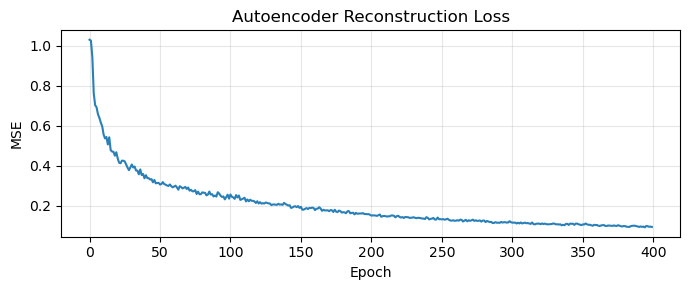

Saved → ae_real.pt


Translating MIL ==> NeuralNetwork Ops: 100%|██████████| 90/90 [00:00<00:00, 5147.09 ops/s]


✅ Success! CoreML model saved as SquatAutoencoder.mlmodel


In [42]:
N_CHANNELS = X_norm.shape[2]  # 21 (12 kine + 9 IMU)

class ConvAE(nn.Module):
    def __init__(self, in_ch, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64,    32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, latent_dim, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent_dim, 32, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(32, 64, kernel_size=4, stride=2, padding=1), nn.ReLU(),
            nn.Conv1d(64, in_ch, kernel_size=3, padding=1),
        )

    def forward(self, x):
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        if x_hat.shape[-1] != x.shape[-1]:
            x_hat = nn.functional.interpolate(x_hat, size=x.shape[-1])
        return x_hat

    def recon_error(self, x):
        with torch.no_grad():
            return ((x - self.forward(x))**2).mean(dim=(1,2)).cpu().numpy()

# Train only on correct-squat windows (all we have)
ae   = ConvAE(in_ch=N_CHANNELS, latent_dim=32).to(DEVICE)
opt  = torch.optim.Adam(ae.parameters(), lr=1e-3)
crit = nn.MSELoss()

# ── Train AE on CORRECT squats only ───────────────────────
correct_mask = (y_train == 0)
X_train_correct = X_train[correct_mask]

print(f'AE training on {len(X_train_correct)} correct-squat windows only')
print(f'(Holding out {(y_train==1).sum()} knee_cave windows from AE training)')

# Then use X_train_correct instead of X_train in the DataLoader
Xt = torch.FloatTensor(X_train_correct).permute(0,2,1)
loader = DataLoader(TensorDataset(Xt), batch_size=16, shuffle=True)
losses = []
EPOCHS = 400
for ep in range(1, EPOCHS+1):
    ae.train()
    ep_loss = 0
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        opt.zero_grad()
        loss = crit(ae(xb), xb)
        loss.backward(); opt.step()
        ep_loss += loss.item()
    ep_loss /= len(loader)
    losses.append(ep_loss)
    if ep % 20 == 0:
        print(f'  Epoch {ep:3d}/{EPOCHS} | recon_loss={ep_loss:.6f}')

torch.save(ae.state_dict(), 'ae_real.pt')

# Loss curve
plt.figure(figsize=(7,3))
plt.plot(losses, color='#2980B9'); plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('Autoencoder Reconstruction Loss'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('ae_loss_real.png', dpi=120); plt.show()
print('Saved → ae_real.pt')

import coremltools as ct
import torch

# 1. Setup Model
ae.eval()
ae.to('cpu')

# 2. Correct Shape: (Batch, Channels, Time) -> (1, 21, 43)
dummy_input = torch.randn(1, len(ALL_FEATURES), WIN_LEN)

# 3. Trace
traced_model = torch.jit.trace(ae, dummy_input)

# 4. Convert with FORCED "NeuralNetwork" format
# This avoids the 'BlobWriter' error on Windows
mlmodel = ct.convert(
    traced_model,
    inputs=[ct.TensorType(name="input_signals", shape=dummy_input.shape)],
    convert_to="neuralnetwork"  # <--- CRITICAL FIX
)

# 5. Add Metadata
mlmodel.short_description = "Detects squat form anomalies (Convolutional Autoencoder)."
mlmodel.input_description["input_signals"] = f"Window of {WIN_LEN} frames with {len(ALL_FEATURES)} features."

# 6. Save as .mlmodel (instead of .mlpackage)
mlmodel.save("SquatAutoencoder.mlmodel")

print("✅ Success! CoreML model saved as SquatAutoencoder.mlmodel")

In [ ]:
# ── Per-channel reconstruction error ──────────────────────
# Which channels drive the error most → tells you which signals are most informative

ae.eval()
Xt_test = torch.FloatTensor(X_test).permute(0,2,1).to(DEVICE)

with torch.no_grad():
    x_hat = ae(Xt_test).cpu().numpy()           # (N, C, T)
    x_orig = X_test.transpose(0, 2, 1)          # (N, C, T)

per_channel_err = ((x_orig - x_hat)**2).mean(axis=(0,2))  # (C,)

plt.figure(figsize=(12, 4))
colors = ['#9B59B6']*12 + ['#2980B9']*9
bars = plt.bar(ALL_FEATURES, per_channel_err, color=colors, edgecolor='white')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('Mean Reconstruction Error (MSE)')
plt.title('Per-Channel Reconstruction Error — higher = more informative signal', fontweight='bold')
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='#9B59B6', label='Kinematics'),
                    Patch(color='#2980B9', label='IMU')], fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ae_channel_error.png', dpi=130, bbox_inches='tight')
plt.show()

# Top 5 most informative channels
top5 = sorted(zip(ALL_FEATURES, per_channel_err), key=lambda x: x[1], reverse=True)[:5]
print('Top 5 most variable channels (AE error):')
for name, err in top5:
    print(f'  {name:<25s}: {err:.6f}')

In [ ]:
# ── AE anomaly validation — the critical test ──────────────
ae.eval()

# Get errors for ALL windows by class
errors_correct  = []
errors_cave     = []

for i in range(len(X_norm)):
    xt = torch.FloatTensor(X_norm[i:i+1]).permute(0,2,1).to(DEVICE)
    err = ae.recon_error(xt)[0]
    if y[i] == 0:
        errors_correct.append(err)
    else:
        errors_cave.append(err)

errors_correct = np.array(errors_correct)
errors_cave    = np.array(errors_cave)

threshold = np.percentile(errors_correct, 85)
DEPLOY_THRESHOLD = threshold
print(f'Deployment threshold: {DEPLOY_THRESHOLD:.4f}')

print(f'Correct squats  — mean: {errors_correct.mean():.4f}  std: {errors_correct.std():.4f}')
print(f'Knee cave       — mean: {errors_cave.mean():.4f}  std: {errors_cave.std():.4f}')
print(f'Threshold (95th pct correct): {threshold:.4f}')
print(f'Knee cave windows above threshold: {(errors_cave > threshold).sum()}/{len(errors_cave)} ({100*(errors_cave>threshold).mean():.0f}%)')
print(f'Correct windows above threshold:   {(errors_correct > threshold).sum()}/{len(errors_correct)} ({100*(errors_correct>threshold).mean():.0f}%)')

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(errors_correct, bins=25, alpha=0.6, color='#27AE60', label=f'Correct squats (n={len(errors_correct)})')
ax.hist(errors_cave,    bins=25, alpha=0.6, color='#E74C3C', label=f'Knee cave (n={len(errors_cave)})')
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold:.3f}')
ax.set_xlabel('Reconstruction Error (MSE)'); ax.set_ylabel('Window count')
ax.set_title('AE Anomaly Detection — Error Distribution by Class', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ae_threshold_validation.png', dpi=130)
plt.show()

for pct in [70, 75, 80, 85, 90, 95]:
    t = np.percentile(errors_correct, pct)
    tp = (errors_cave > t).mean() * 100
    fp = (errors_correct > t).mean() * 100
    print(f'  {pct}th pct | threshold={t:.3f} | cave detected={tp:.0f}% | false alarms={fp:.0f}%')

## Cell 8 — SVM

⚠️ **Needs ≥2 classes to train.** Runs a quick check now.  
Add a bad squat trial to `TRIAL_REGISTRY` in Cell 6, re-run from Cell 6, then this cell will work fully.

In [ ]:
RESULTS = {}

CLASS_NAMES = ['correct', 'knee_cave']  # extend if you add more classes

def evaluate(model_name, y_true, y_pred):
    present = np.unique(y_true)
    names   = [CLASS_NAMES[i] for i in present if i < len(CLASS_NAMES)]
    print(f'\n{"="*50}')
    print(f'  {model_name}')
    print(f'{"="*50}')
    print(classification_report(y_true, y_pred, labels=present, target_names=names))
    cm = confusion_matrix(y_true, y_pred, labels=present)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, linewidths=0.5)
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    fname = f'cm_{model_name.lower().replace(" ","_")}.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight'); plt.show()
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    RESULTS[model_name] = {'macro_f1': round(f1,3)}
    print(f'Macro F1: {f1:.3f}')

# Feature extraction for SVM
def extract_features(window):
    # window: (T, C)
    feats = []
    for i in range(window.shape[1]):
        col = window[:, i]
        feats += [col.mean(), col.std(), col.max()-col.min(), np.sum(col**2)]
    return np.array(feats)

n_classes = len(np.unique(y))
if n_classes < 2:
    print('⚠  Only 1 class in dataset — SVM needs ≥2 classes.')
    print('   Add a knee_cave trial to TRIAL_REGISTRY in Cell 6 and re-run.')
    print()
    print('   SVM code is ready — it will run automatically once you add more trials.')
else:
    X_tr_f = np.array([extract_features(w) for w in X_train])
    X_te_f = np.array([extract_features(w) for w in X_test])

    svm = Pipeline([('sc', StandardScaler()),
                    ('svm', SVC(kernel='rbf', C=1, gamma='scale', probability=True, class_weight='balanced'))])
    svm.fit(X_tr_f, y_train)
    joblib.dump(svm, 'svm_real.pkl')
    evaluate('SVM', y_test, svm.predict(X_te_f))
    print('Saved → svm_real.pkl')

## Cell 9 — 1D-CNN

In [ ]:
class SquatCNN(nn.Module):
    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(32, n_classes),
        )
    def forward(self, x): return self.net(x)  # x: (B, C, T)

def train_torch(model, X_tr, y_tr, X_te, y_te, epochs=60, lr=1e-3, name='model'):
    model = model.to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_weight_tensor)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=6, factor=0.5)

    Xt  = torch.FloatTensor(X_tr).permute(0,2,1)
    yt  = torch.LongTensor(y_tr)
    Xv  = torch.FloatTensor(X_te).permute(0,2,1)
    yv  = torch.LongTensor(y_te)
    loader = DataLoader(TensorDataset(Xt, yt), batch_size=16, shuffle=True)

    tl, vl, best, best_state = [], [], np.inf, None
    for ep in range(1, epochs+1):
        model.train()
        el = sum(crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                 for xb, yb in loader) / len(loader)
        model.eval()
        with torch.no_grad():
            vl_ = crit(model(Xv.to(DEVICE)), yv.to(DEVICE)).item()
        tl.append(el); vl.append(vl_); sched.step(vl_)
        if vl_ < best:
            best = vl_
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
        if ep % 20 == 0: print(f'  Epoch {ep}/{epochs} | train={el:.4f} val={vl_:.4f}')
    model.load_state_dict(best_state)

    plt.figure(figsize=(7,3))
    plt.plot(tl, label='Train'); plt.plot(vl, label='Val')
    plt.title(f'{name} Loss'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f'loss_{name}.png', dpi=120); plt.show()
    return model

def predict_torch(model, X_norm):
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(X_norm).permute(0,2,1).to(DEVICE))
    return logits.argmax(1).cpu().numpy()

n_classes = len(np.unique(y))
if n_classes < 2:
    print('⚠  Only 1 class — 1D-CNN needs ≥2 classes.')
    print('   Add a knee_cave trial to TRIAL_REGISTRY in Cell 6 and re-run.')
else:
    cnn = SquatCNN(in_ch=N_CHANNELS, n_classes=n_classes)
    cnn = train_torch(cnn, X_train, y_train, X_test, y_test, epochs=60, name='cnn')
    torch.save(cnn.state_dict(), 'cnn_real.pt')
    evaluate('1D-CNN', y_test, predict_torch(cnn, X_test))
    print('Saved → cnn_real.pt')

## Cell 10 — TCN

In [ ]:
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, k, d):
        super().__init__()
        self.pad  = (k-1)*d
        self.conv = nn.Conv1d(in_ch, out_ch, k, dilation=d, padding=0)
    def forward(self, x):
        return self.conv(nn.functional.pad(x, (self.pad, 0)))

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k, d):
        super().__init__()
        self.c1   = CausalConv1d(in_ch, out_ch, k, d)
        self.bn1  = nn.BatchNorm1d(out_ch)
        self.c2   = CausalConv1d(out_ch, out_ch, k, d)
        self.bn2  = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(0.2)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        r = self.skip(x)
        x = self.drop(self.relu(self.bn1(self.c1(x))))
        x = self.drop(self.relu(self.bn2(self.c2(x))))
        return self.relu(x + r)

class SquatTCN(nn.Module):
    def __init__(self, in_ch, n_classes, hidden=64, k=3):
        super().__init__()
        self.tcn  = nn.Sequential(
            TCNBlock(in_ch,   hidden, k, 1),
            TCNBlock(hidden,  hidden, k, 2),
            TCNBlock(hidden,  hidden, k, 4),
            TCNBlock(hidden,  hidden, k, 8),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, n_classes),
        )
    def forward(self, x): return self.head(self.tcn(x))

n_classes = len(np.unique(y))
if n_classes < 2:
    print('⚠  Only 1 class — TCN needs ≥2 classes.')
    print('   Add a knee_cave trial to TRIAL_REGISTRY in Cell 6 and re-run.')
else:
    tcn = SquatTCN(in_ch=N_CHANNELS, n_classes=n_classes)
    tcn = train_torch(tcn, X_train, y_train, X_test, y_test, epochs=60, name='tcn')
    torch.save(tcn.state_dict(), 'tcn_real.pt')
    evaluate('TCN', y_test, predict_torch(tcn, X_test))
    print('Saved → tcn_real.pt')

In [ ]:
# Force reload from current Cell 6 output
# assert np.sum(y_test==0) > 0, f"y_test has no correct windows! dist={np.bincount(y_test)} — re-run Cell 6 first"
# assert np.sum(y_test==1) > 0, f"y_test has no knee_cave windows! dist={np.bincount(y_test)}"
# print(f"y_test confirmed: correct={np.sum(y_test==0)}, knee_cave={np.sum(y_test==1)}")

# ── Detailed breakdown of what each model is actually doing ──
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

models_preds = {}

# SVM
X_te_f = np.array([extract_features(w) for w in X_test])
models_preds['SVM'] = svm.predict(X_te_f)

# CNN
models_preds['1D-CNN'] = predict_torch(cnn, X_test)

# TCN
models_preds['TCN'] = predict_torch(tcn, X_test)

# Plot all confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
class_names = ['correct', 'knee_cave']
present_classes = sorted(np.unique(np.concatenate([y_test] + list(models_preds.values()))))
present_names   = [class_names[i] for i in present_classes]

for ax, (name, preds) in zip(axes, models_preds.items()):
    f1 = f1_score(y_test, preds, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, preds, labels=present_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=present_names, yticklabels=present_names,
                ax=ax, linewidths=0.5)
    ax.set_title(f'{name}  (F1={f1:.3f})', fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    print(f'\n{name}:')
    print(f'  true  dist: {np.bincount(y_test, minlength=2)}')
    print(f'  pred  dist: {np.bincount(preds, minlength=2)}')
    print(classification_report(y_test, preds,
                                 labels=present_classes,
                                 target_names=present_names,
                                 zero_division=0))

plt.suptitle('Model Comparison — Confusion Matrices', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'\nTrain — correct: {np.sum(y_train==0)}, knee_cave: {np.sum(y_train==1)}')
print(f'Test  — correct: {np.sum(y_test==0)},  knee_cave: {np.sum(y_test==1)}')

## Cell 11 — What's Working Now + Next Steps

In [ ]:
print('='*55)
print('  STATUS SUMMARY')
print('='*55)

checks = [
    ('Kinematics loaded & parsed',          True),
    ('Watch IMU loaded',                    True),
    ('Resampled & aligned to common grid',  True),
    ('Sliding windows generated',           True),
    ('Autoencoder trained (good squat)',    True),
    ('Per-channel importance plot',         True),
    ('SVM / CNN / TCN',len(np.unique(y)) >= 2),
]
for label, done in checks:
    icon = '✓' if done else '○'
    print(f'  {icon}  {label}')


if RESULTS:
    print('MODEL RESULTS:')
    for m, r in RESULTS.items():
        print(f'  {m:<20s} macro F1 = {r["macro_f1"]:.3f}')